## Ссылка на датасет
https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques
## Краткое описание
Цены на дома, также с такими признаками как внутренний дворик, наличие мест для огня, количества различных комнат и тп.

## Выполнение задания А:

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("1. Загрузка данных")
df = pd.read_csv('sample_data/train.csv')

1. Загрузка данных


In [2]:
df.head(20)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [3]:
df.tail(20)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1440,1441,70,RL,79.0,11526,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,191000
1441,1442,120,RM,NaN,4426,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,149300
1442,1443,60,FV,85.0,11003,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,310000
1443,1444,30,RL,NaN,8854,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,121000
1444,1445,20,RL,63.0,8500,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,11,2007,WD,Normal,179600
1445,1446,85,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,129000
1446,1447,20,RL,NaN,26142,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,157900
1447,1448,60,RL,80.0,10000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,240000
1448,1449,50,RL,70.0,11767,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdWo,NaN,0,5,2007,WD,Normal,112000
1449,1450,180,RM,21.0,1533,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2006,WD,Abnorml,92000


In [4]:
df.shape

(1460, 81)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [6]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [7]:
df.describe(include=["object", "string"])

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


In [8]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

## Выполнение задания B:

In [10]:
df["LotFrontage"]=df["LotFrontage"].fillna(df["LotFrontage"].mean())

Заполнение пустых числовых значений средним значением, так как данные числовые, то можно использовать среднее чтобы не потерять нужные для анализа данные в дургих колонках.

In [11]:
df["Fireplaces"]=df["Fireplaces"].fillna(df["Fireplaces"].median())

In [12]:
mode_value=df["MasVnrType"].mode()[0]
df["MasVnrType"]=df["MasVnrType"].fillna(mode_value)

Для категориальных колонок используется мода — самое частое значение.

## Выполнение задания С (Статистика):

In [13]:
stats = []

for col in df.select_dtypes(include=["int64", "float64"]):
    stats.append({
        "column": col,
        "min": df[col].min(),
        "max": df[col].max(),
        "mean": df[col].mean(),
        "median": df[col].median(),
        "mode": df[col].mode()[0]
    })

stats_df = pd.DataFrame(stats)
stats_df

,column,min,max,mean,median,mode
0,Id,1.0,1460.0,730.500000,730.500000,1.000000
1,MSSubClass,20.0,190.0,56.897260,50.000000,20.000000
2,LotFrontage,21.0,313.0,70.049958,70.049958,70.049958
3,LotArea,1300.0,215245.0,10516.828082,9478.500000,7200.000000
4,OverallQual,1.0,10.0,6.099315,6.000000,5.000000
5,OverallCond,1.0,9.0,5.575342,5.000000,5.000000
6,YearBuilt,1872.0,2010.0,1971.267808,1973.000000,2006.000000
7,YearRemodAdd,1950.0,2010.0,1984.865753,1994.000000,1950.000000
8,MasVnrArea,0.0,1600.0,103.685262,0.000000,0.000000
9,BsmtFinSF1,0.0,5644.0,443.639726,383.500000,0.000000


Таблица с числовыми данными расширенная, для каждого столбца

In [14]:
stats = []

for col in df.select_dtypes(include=["int64", "float64"]):
    stats.append({
        "column": col,
        "q05": df[col].quantile(0.05),
        "q25": df[col].quantile(0.25),
        "q50": df[col].quantile(0.50),
        "q75": df[col].quantile(0.75),
        "q95": df[col].quantile(0.95)
    })

stats_df = pd.DataFrame(stats)
stats_df

,column,q05,q25,q50,q75,q95
0,Id,73.95,365.75,730.500000,1095.25,1387.05
1,MSSubClass,20.00,20.00,50.000000,70.00,160.00
2,LotFrontage,35.95,60.00,70.049958,79.00,104.00
3,LotArea,3311.70,7553.50,9478.500000,11601.50,17401.15
4,OverallQual,4.00,5.00,6.000000,7.00,8.00
5,OverallCond,4.00,5.00,5.000000,6.00,8.00
6,YearBuilt,1916.00,1954.00,1973.000000,2000.00,2007.00
7,YearRemodAdd,1950.00,1967.00,1994.000000,2004.00,2007.00
8,MasVnrArea,0.00,0.00,0.000000,166.00,456.00
9,BsmtFinSF1,0.00,0.00,383.500000,712.25,1274.00


Таблица с перцентелями

In [15]:
stats = []

for col in df.select_dtypes(include=["int64", "float64"]):
    stats.append({
        "column": col,
        "variance": df[col].var(),
        "skew": df[col].skew(),
        "kurtosis": df[col].kurtosis()
    })

stats_df = pd.DataFrame(stats)
stats_df

,column,variance,skew,kurtosis
0,Id,1.777550e+05,0.000000,-1.200000
1,MSSubClass,1.789338e+03,1.407657,1.580188
2,LotFrontage,4.850576e+02,2.384950,21.848165
3,LotArea,9.962565e+07,12.207688,203.243271
4,OverallQual,1.912679e+00,0.216944,0.096293
5,OverallCond,1.238322e+00,0.693067,1.106413
6,YearBuilt,9.122154e+02,-0.613461,-0.439552
7,YearRemodAdd,4.262328e+02,-0.503562,-1.272245
8,MasVnrArea,3.278497e+04,2.669084,10.082417
9,BsmtFinSF1,2.080255e+05,1.685503,11.118236


Так, ну у меня получается дисперсия показывает насколько сильно данные отходят от среднего значения. Ассиметрия показывает, насколько данные смещены от центра если больше нуля то они меньше среднего, а если больше то наоборот. Эксцесс показывает количество выбросов с большим весом.

## Выполнение задания D:

In [16]:
#df = pd.get_dummies(df, columns=["MSZoning","Street"])
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [17]:
df["PricePerGrLivArea"]=df["SalePrice"]/df["GrLivArea"]
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,PricePerGrLivArea
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,121.929825
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,143.819334
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,125.139978
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,81.537566
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,113.739763


In [18]:
from category_encoders import HashingEncoder

#cols_to_hash = ["Neighborhood"]
#encoder = HashingEncoder(cols=cols_to_hash, n_components=8)
#df = encoder.fit_transform(df)
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,PricePerGrLivArea
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,121.929825
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,143.819334
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,125.139978
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,81.537566
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,113.739763


Я тут накосячил, вообщем я понял что перезаписал свои данные и повторно уже их не использовать, корректно было создавать новую датафрейм, чтобы не возникало проблемы, я понял свою ошибку.

## Выполнение задания E:

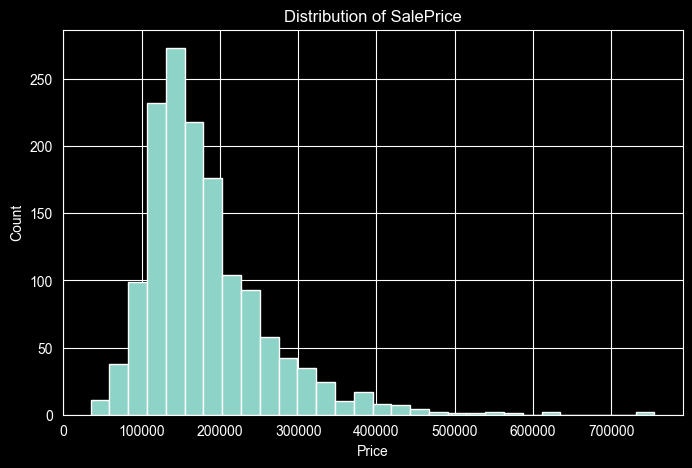

In [19]:
plt.figure(figsize=(8,5))
plt.hist(df["SalePrice"], bins=30)
plt.title("Distribution of SalePrice")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

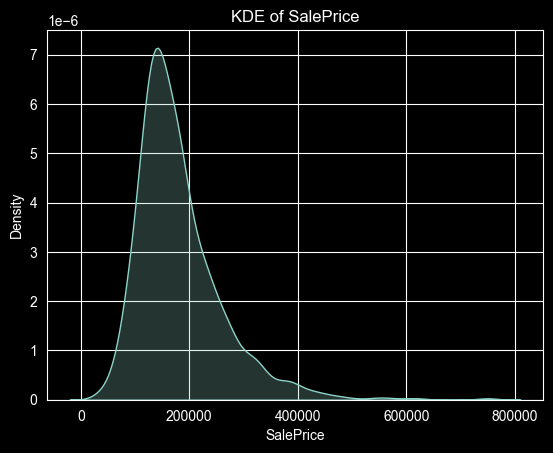

In [20]:
sns.kdeplot(df["SalePrice"], fill=True)
plt.title("KDE of SalePrice")
plt.show()

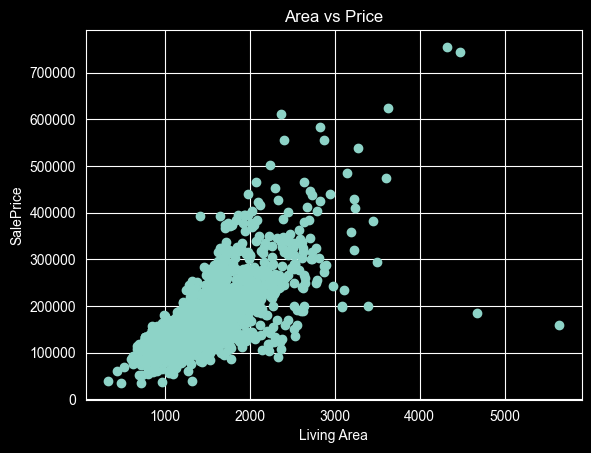

In [21]:
plt.scatter(df["GrLivArea"], df["SalePrice"])
plt.xlabel("Living Area")
plt.ylabel("SalePrice")
plt.title("Area vs Price")
plt.show()

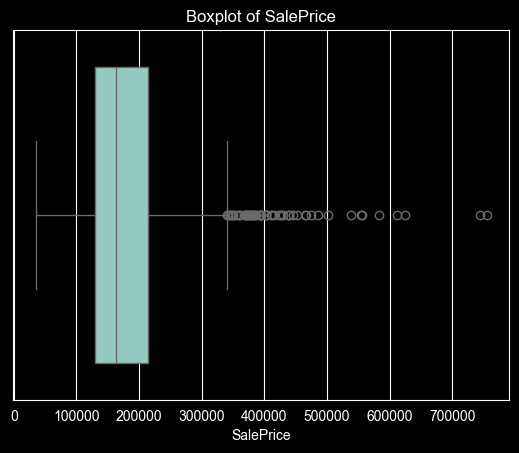

In [22]:
sns.boxplot(x=df["SalePrice"])
plt.title("Boxplot of SalePrice")
plt.show()

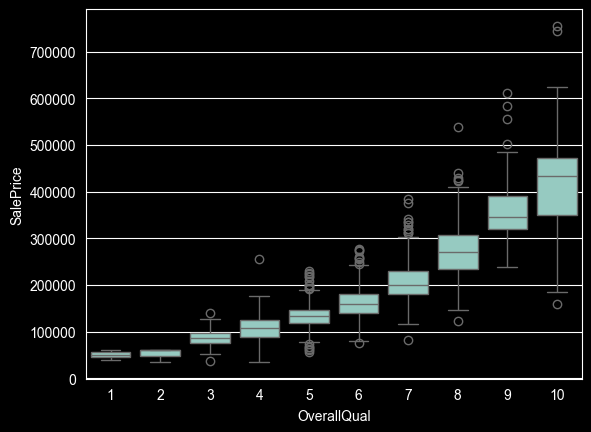

In [23]:
sns.boxplot(x="OverallQual", y="SalePrice", data=df)
plt.show()

Видны выбросы в цене. Также более высокий уровень качества дома связан с более высокой ценой.

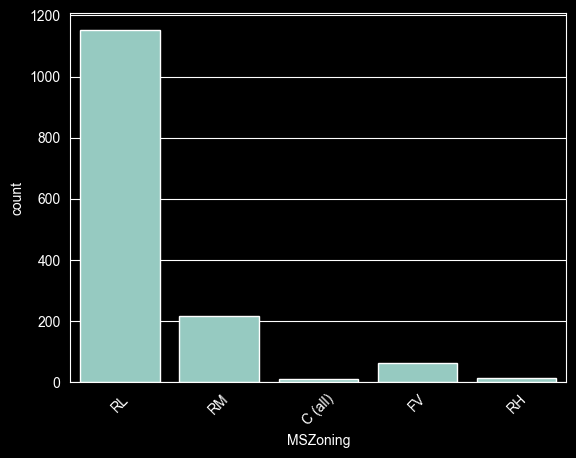

In [24]:
sns.countplot(x="MSZoning", data=df)
plt.xticks(rotation=45)
plt.show()

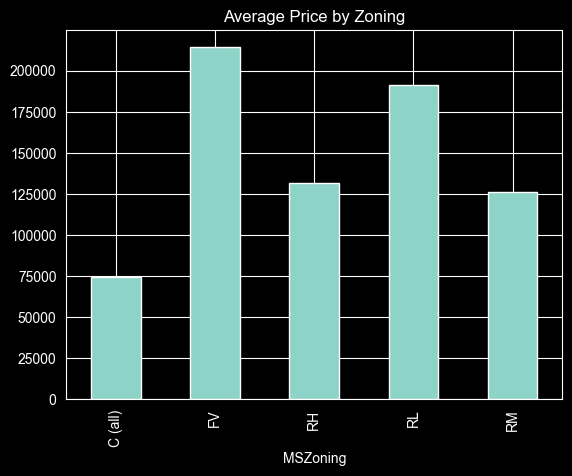

In [25]:
df.groupby("MSZoning")["SalePrice"].mean().plot(kind="bar")
plt.title("Average Price by Zoning")
plt.show()

Разные зоны имеют различную среднюю стоимость домов.

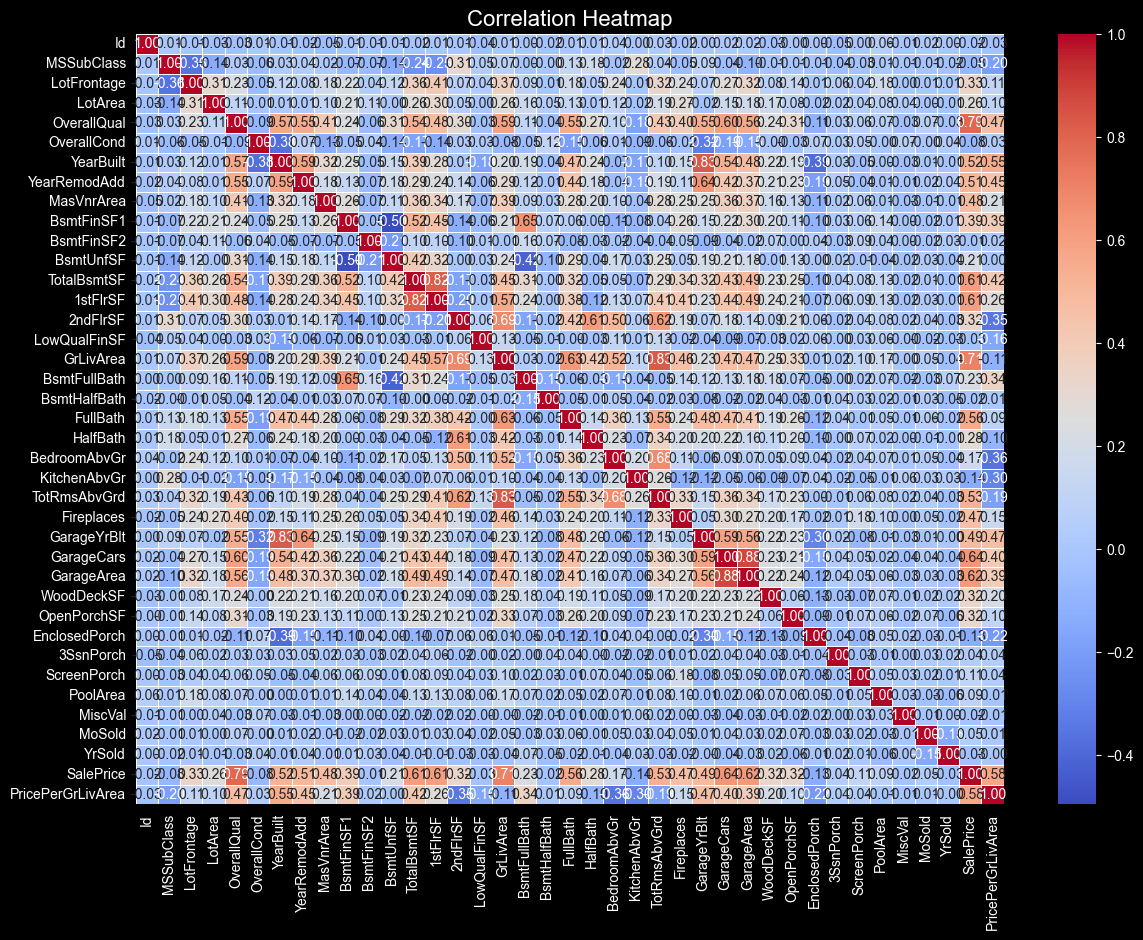

In [26]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,        # показывает числа
    fmt=".2f",         # 2 знака после запятой
    cmap="coolwarm",
    linewidths=0.5     # линии между ячейками
)

plt.title("Correlation Heatmap", fontsize=16)
plt.show()

In [27]:
corr["SalePrice"].sort_values(ascending=False).head(10)

SalePrice            1.000000
OverallQual          0.790982
GrLivArea            0.708624
GarageCars           0.640409
GarageArea           0.623431
TotalBsmtSF          0.613581
1stFlrSF             0.605852
PricePerGrLivArea    0.575505
FullBath             0.560664
TotRmsAbvGrd         0.533723
Name: SalePrice, dtype: float64

In [28]:
fig = px.scatter(
    df,
    x="GrLivArea",
    y="SalePrice",
    color="OverallQual",
    hover_data=["Neighborhood"]
)

fig.show()

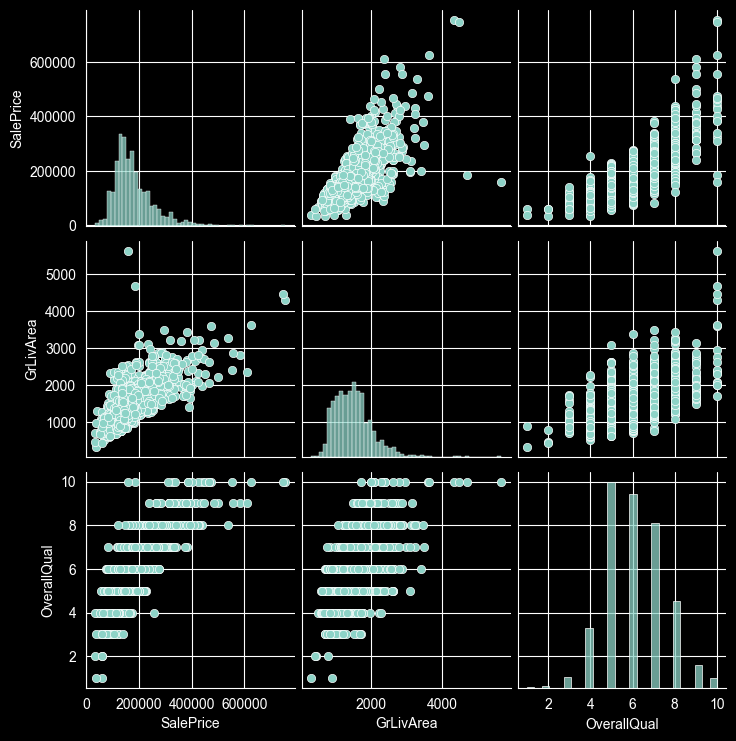

In [29]:
sns.pairplot(df[["SalePrice","GrLivArea","OverallQual"]])

## Выполнение задания F:

### Выводы по тому, что "Что я понял про датасет"
1. С ценой самая высокая корелляция идет с GrLivArea, OverallQual, 1stFlrSF, GarageCars (на мое удивление). С первыми 3 был уверен что будет высокая корелляция, но вот кореляция с GarageCars оказалась неожиданной.
2. Также было выяснено, что в датасете много не нужных данных, по типу PoolArea и Porch, но не нужны они потому что в датасете было мало домов с бассейнами, и они не сильно влияли на стоимость, что легко увидеть посмотрев на heatmap.
3. Наличие большого количества пустых столбцов Alley, MasVnrArea, FireplaceQu, PoolQC, MiscFeature, Fence у которых отсутствует информация более чем в 1000 столбцах из 1400, что явно вызывает проблемы при дальнейшей работе модели(также у них низкая кореляция с другими параметрами).
4. Распределение SalePrice имеет правостороннюю асимметрию: большинство домов имеют среднюю цену, а дорогие дома встречаются редко.
5. В данных присутствуют выбросы, особенно в признаках GrLivArea и SalePrice, где некоторые дома имеют значительно большую площадь или стоимость по сравнению с остальными.
6. Признак OverallQual оказывает сильное влияние на цену: дома с более высоким качеством значительно дороже.
7. Некоторые категориальные признаки, такие как Neighborhood, также могут оказывать существенное влияние на цену, несмотря на то что это не числовые данные.

### Гипотезы и наблюдения
- Признаки, связанные с размером и качеством дома (`GrLivArea`, `OverallQual`), оказывают наибольшее влияние на стоимость недвижимости. Предполагается, что увеличение площади и качества напрямую повышает цену.
- Количество мест в гараже (`GarageCars`) имеет значительное влияние на цену дома, что может свидетельствовать о том, что наличие большого гаража является важным фактором для покупателей.
- Категориальный признак `Neighborhood` может существенно влиять на стоимость жилья, так как расположение дома является одним из ключевых факторов ценообразования.
- Наличие выбросов в признаках `GrLivArea` и `SalePrice` может искажать модель, поэтому предполагается, что их обработка (например, удаление или логарифмирование) улучшит качество предсказаний.
- Признаки с большим количеством пропусков (`PoolQC`, `Fence`, `MiscFeature` и др.) либо не являются значимыми, либо требуют особого подхода к обработке, так как их использование “как есть” может ухудшить модель.

### Что бы вы сделали дальше
В дальнейшем я бы хотел поудалять ненужные признаки, и использовать линейную регрессию, как обычно используют для этого датасета, для предсказывания `SalePrice`. Также хотлеось бы дальше изучать влияние некоторых признаков на модель уже в дальнейшем и как лучше заменять пропуски в данных, для улучшения эффективности модели, ведь хорошие данные очень важны.

### Использование AI
ИИ я использовал как помощь с кодом, так как питон и библиотеки я только начал изучать, также как обьяснение, а зачем я это сделал. Но ответы на вопросы зачем я это делаю я больше серчил в интернете нежели, используя ИИ. Ну и секция с закоменченным кодом, это я сам исправлял, так как мне выдавало ошибку, ну и там я сам дописывал код.